In [ ]:
!pip install camel-tools

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.3/122.3 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 125.7 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=90e64f2e92266ff71ebfe3117a0bb57c42965562896fda814a2fd7ca6de86ad6
  Stored 

In [1]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.2/332.2 kB 7.2 MB/s eta 0:00:00


In [2]:
from pypdf import PdfReader
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [3]:
from datasets import load_dataset


In [4]:

ds2 = load_dataset("Rabe3/saudi-dialect-rag")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

saudi_dialect_rag_train.json:   0%|          | 0.00/15.4M [00:00<?, ?B/s]

saudi_dialect_rag_val.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/10022 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1114 [00:00<?, ? examples/s]

In [5]:
ds2

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 10022
    })
    validation: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 1114
    })
})

In [6]:
small_ds = ds2['train'].select(range(300))

In [7]:
small_ds[0]

{'instruction': 'أنت سيرا، مساعد ذكي متخصص في أنظمة ولوائح الكهرباء في المملكة العربية السعودية. تتكلم باللهجة السعودية وتجاوب بأسلوب واضح ومفيد. أجب على السؤال بناءً على السياق أدناه باللهجة السعودية\n\nالسياق:\nأطلق النادي الرياضي مبادرة خاصة لشهر رمضان المبارك تهدف إلى تيسير تجربة التدريب للصائمين، حيث تم تعديل مواعيد التمارين لتكون بعد صلاة الفجر، وفي وقت العصر، وبعد صلاة التراويح، كما سيقوم النادي بتوفير وجبات إفطار مجانية للمشتركين تتضمن التمر، والشوربة، والسمبوسة، ومشروبات الطاقة.\n\nالمحادثة السابقة:\nالمستخدم: السلام عليكم، ياخي سمعت يقولون انكم بتسوون مبادرات جديدة في رمضان، وش سالفتها؟\nالمساعد: وعليكم السلام، والله صحيح، بنعدل أوقات التمارين وبنوفر وجبات إفطار بعد المغرب.\nالمستخدم: ما شاء الله، طيب وش أوقات التمارين الجديدة؟\nالمساعد: بعد الفجر وعند العصر وبعد التراويح، علشان اللي يصوم يقدر يتدرب مرتاح.\n\nالسؤال: تسلم، وربي انك فكرت في كل شي، بس وش نوع وجبات الإفطار؟',
 'input': '',
 'output': 'بنقدم تمر، شوربة، سمبوسة، ومشروبات طاقة بشكل مجاني.'}

In [8]:
instruction_data = []

In [9]:
for row in small_ds:
    instruction_data.append({
        "instruction": row["instruction"],
        "input": row["input"],
        "output": row["output"]
    })

In [10]:
target_sentence = "أنت سيرا، مساعد ذكي متخصص في أنظمة ولوائح الكهرباء في المملكة العربية السعودية. تتكلم باللهجة السعودية وتجاوب بأسلوب واضح ومفيد. أجب على السؤال بناءً على السياق أدناه باللهجة السعودية"
replacement = ""

for row in instruction_data:
    if "instruction" in row and isinstance(row["instruction"], str):
        row["instruction"] = row["instruction"].replace(target_sentence, replacement)

print("تم تنظيف البيانات بنجاح! إليك مثال بعد التعديل:\n")
print(instruction_data[0]['instruction'])

تم تنظيف البيانات بنجاح! إليك مثال بعد التعديل:



السياق:
أطلق النادي الرياضي مبادرة خاصة لشهر رمضان المبارك تهدف إلى تيسير تجربة التدريب للصائمين، حيث تم تعديل مواعيد التمارين لتكون بعد صلاة الفجر، وفي وقت العصر، وبعد صلاة التراويح، كما سيقوم النادي بتوفير وجبات إفطار مجانية للمشتركين تتضمن التمر، والشوربة، والسمبوسة، ومشروبات الطاقة.

المحادثة السابقة:
المستخدم: السلام عليكم، ياخي سمعت يقولون انكم بتسوون مبادرات جديدة في رمضان، وش سالفتها؟
المساعد: وعليكم السلام، والله صحيح، بنعدل أوقات التمارين وبنوفر وجبات إفطار بعد المغرب.
المستخدم: ما شاء الله، طيب وش أوقات التمارين الجديدة؟
المساعد: بعد الفجر وعند العصر وبعد التراويح، علشان اللي يصوم يقدر يتدرب مرتاح.

السؤال: تسلم، وربي انك فكرت في كل شي، بس وش نوع وجبات الإفطار؟


In [37]:
instruction_data[2]

{'instruction': '\n\nالسياق:\nيتبادل حسين وابن عمه زيد الحديث حول مستويات فرق كرة القدم هذا الموسم، حيث أشادا بأداء نادي الهلال الثابت، بينما عبّر حسين عن تشجيعه لنادي النصر وترقبه لمباراته الحماسية المقررة غداً، وقد اتفق الطرفان على مشاهدة المباراة سوياً في الاستراحة برفقة الأصدقاء.\n\nالمحادثة السابقة:\nالمستخدم: وش رايك بذا الموسم؟ الهلال كويس ولا؟\nالمساعد: والله الهلال دايم كويس. انت وش تشجع؟\n\nالسؤال: أحب النصر، تدري انه بيلعب بكرة؟',
 'input': '',
 'output': 'ايه، والله يقولون المباراة بتكون حماسية. وين بتشوفها؟'}

In [15]:
import json
with open("/content/more_data.txt", "r", encoding="utf-8") as file:
      record3 = file.read()

In [18]:
type(record3)

str

In [20]:
reader1 = PdfReader('/content/saudia-min.pdf')
reader2 = PdfReader('/content/poetry.pdf')



print(f"Total pages: {len(reader2.pages)}")

Total pages: 96


In [21]:
text = ""

In [26]:
for page in reader1.pages:
    text += page.extract_text()


In [27]:
for page in reader2.pages:
    text += page.extract_text()

In [28]:

text += record3

In [29]:
len(text)

423104

In [ ]:
text = text[:150000]

In [ ]:
text[:15]

In [30]:


import os
import urllib.request

import json
import numpy as np
import tensorflow as tf
from tqdm import tqdm


def download_and_load_gpt2(model_size, models_dir):
    # Validate model size
    allowed_sizes = ("124M", "355M", "774M", "1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    # Define paths
    model_dir = os.path.join(models_dir, model_size)
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
    backup_base_url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2"
    filenames = [
        "checkpoint", "encoder.json", "hparams.json",
        "model.ckpt.data-00000-of-00001", "model.ckpt.index",
        "model.ckpt.meta", "vocab.bpe"
    ]

    # Download files
    os.makedirs(model_dir, exist_ok=True)
    for filename in filenames:
        file_url = os.path.join(base_url, model_size, filename)
        backup_url = os.path.join(backup_base_url, model_size, filename)
        file_path = os.path.join(model_dir, filename)
        download_file(file_url, file_path, backup_url)

    # Load settings and params
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(open(os.path.join(model_dir, "hparams.json"), "r", encoding="utf-8"))
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

    return settings, params


def download_file(url, destination, backup_url=None):
    def _attempt_download(download_url):
        with urllib.request.urlopen(download_url) as response:
            # Get the total file size from headers, defaulting to 0 if not present
            file_size = int(response.headers.get("Content-Length", 0))

            # Check if file exists and has the same size
            if os.path.exists(destination):
                file_size_local = os.path.getsize(destination)
                if file_size == file_size_local:
                    print(f"File already exists and is up-to-date: {destination}")
                    return True  # Indicate success without re-downloading

            block_size = 1024  # 1 Kilobyte

            # Initialize the progress bar with total file size
            progress_bar_description = os.path.basename(download_url)
            with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
                with open(destination, "wb") as file:
                    while True:
                        chunk = response.read(block_size)
                        if not chunk:
                            break
                        file.write(chunk)
                        progress_bar.update(len(chunk))
            return True

    try:
        if _attempt_download(url):
            return
    except (urllib.error.HTTPError, urllib.error.URLError):
        if backup_url is not None:
            print(f"Primary URL ({url}) failed. Attempting backup URL: {backup_url}")
            try:
                if _attempt_download(backup_url):
                    return
            except urllib.error.HTTPError:
                pass

        # If we reach here, both attempts have failed
        error_message = (
            f"Failed to download from both primary URL ({url})"
            f"{' and backup URL (' + backup_url + ')' if backup_url else ''}."
            "\nCheck your internet connection or the file availability.\n"
            "For help, visit: https://github.com/rasbt/LLMs-from-scratch/discussions/273"
        )
        print(error_message)
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


# Alternative way using `requests`
"""
def download_file(url, destination):
    # Send a GET request to download the file in streaming mode
    response = requests.get(url, stream=True)

    # Get the total file size from headers, defaulting to 0 if not present
    file_size = int(response.headers.get("content-length", 0))

    # Check if file exists and has the same size
    if os.path.exists(destination):
        file_size_local = os.path.getsize(destination)
        if file_size == file_size_local:
            print(f"File already exists and is up-to-date: {destination}")
            return

    # Define the block size for reading the file
    block_size = 1024  # 1 Kilobyte

    # Initialize the progress bar with total file size
    progress_bar_description = url.split("/")[-1]  # Extract filename from URL
    with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
        # Open the destination file in binary write mode
        with open(destination, "wb") as file:
            # Iterate over the file data in chunks
            for chunk in response.iter_content(block_size):
                progress_bar.update(len(chunk))  # Update progress bar
                file.write(chunk)  # Write the chunk to the file
"""


def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
    # Initialize parameters dictionary with empty blocks for each layer
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}

    # Iterate over each variable in the checkpoint
    for name, _ in tf.train.list_variables(ckpt_path):
        # Load the variable and remove singleton dimensions
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

        # Process the variable name to extract relevant parts
        variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

        # Identify the target dictionary for the variable
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        # Recursively access or create nested dictionaries
        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        # Assign the variable array to the last key
        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array

    return params

In [31]:

import numpy as np
import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.tokenizer = tokenizer
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True, num_workers=0):
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by n_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec


class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_resid = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)   # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_resid(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_resid(x)
        x = x + shortcut  # Add the original input back

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (B, T) array of indices in the current context
    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Get the idx of the vocab entry with the highest logits value
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))


def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # add batch dimension
    return encoded_tensor


def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)  # remove batch dimension
    return tokenizer.decode(flat.tolist())
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

In [32]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.2,
    "qkv_bias": True
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M).to(device)

print("Downloading and loading OpenAI GPT-2 weights...")
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")
load_weights_into_gpt(model, params)

model.eval()
print("Base model loaded successfully! Ready for Fine-tuning.")

Using device: cuda


checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 69.9kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 3.33MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 177kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:32<00:00, 15.2MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 8.32MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 1.91MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.84MiB/s]


Base model loaded successfully! Ready for Fine-tuning.


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M).to(device)

print("Downloading and loading OpenAI GPT-2 weights...")
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")
load_weights_into_gpt(model, params)

model.eval()
print("Phase 1 Complete: GPT-2 base model loaded successfully!")

train_ratio = 0.90
split_idx = int(train_ratio * len(text))
train_data = text[:split_idx]
val_data = text[split_idx:]

train_loader = create_dataloader_v1(
    train_data,
    batch_size=1,
    max_length=256,
    stride=256,
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=1,
    max_length=256,
    stride=256,
    drop_last=False,
    shuffle=False,
    num_workers=0
)

Using device: cuda
File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe
Phase 1 Complete: GPT-2 base model loaded successfully!


In [34]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

Starting Continued Pretraining on the Arabic PDF...
Ep 1 (Step 000000): Train loss 3.886, Val loss 8.236
Ep 1 (Step 000050): Train loss 2.245, Val loss 2.082
Ep 1 (Step 000100): Train loss 2.099, Val loss 2.160
Ep 1 (Step 000150): Train loss 1.813, Val loss 1.839
Ep 1 (Step 000200): Train loss 1.737, Val loss 1.979
Ep 1 (Step 000250): Train loss 1.647, Val loss 1.660
Ep 1 (Step 000300): Train loss 1.817, Val loss 1.657
Ep 1 (Step 000350): Train loss 1.916, Val loss 1.634
Ep 1 (Step 000400): Train loss 1.681, Val loss 1.689
Ep 1 (Step 000450): Train loss 1.522, Val loss 1.698
Ep 1 (Step 000500): Train loss 1.632, Val loss 1.565
Ep 1 (Step 000550): Train loss 1.335, Val loss 1.428
Ep 1 (Step 000600): Train loss 1.573, Val loss 1.567
Ep 1 (Step 000650): Train loss 1.673, Val loss 1.423
Ep 1 (Step 000700): Train loss 1.465, Val loss 1.509
Ep 1 (Step 000750): Train loss 1.522, Val loss 1.463
Ep 1 (Step 000800): Train loss 1.637, Val loss 1.430
Ep 1 (Step 000850): Train loss 1.718, Val loss 

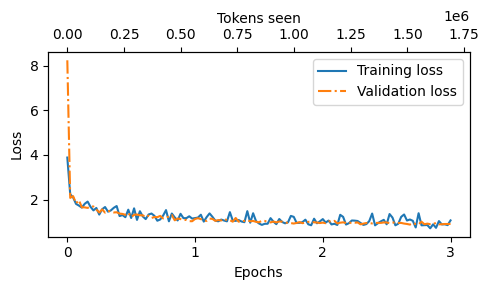

In [35]:

tokenizer = tiktoken.get_encoding("gpt2")
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs_pdf = 3

print("Starting Continued Pretraining on the Arabic PDF...")

train_losses, val_losses, tokens_seen = train_model_simple(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs_pdf,
    eval_freq=50,
    eval_iter=5,
    start_context="في هذا المستند",
    tokenizer=tokenizer
)

torch.save(model.state_dict(), "gpt2_arabic_pretrained.pth")
print("Pretraining on Arabic PDF complete! Model saved.")

epochs_tensor = torch.linspace(0, num_epochs_pdf, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [36]:
import torch
from torch.utils.data import Dataset, DataLoader
from functools import partial


def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['input']}" if entry.get("input") else ""
    return instruction_text + input_text

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []

        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(tokenizer.encode(full_text))

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

def custom_collate_fn(batch, pad_token_id=50256, ignore_index=-100, allowed_max_length=None, device="cpu"):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        pad_len = batch_max_length - len(new_item)

        inputs = new_item[:-1] + [pad_token_id] * pad_len
        targets = new_item[1:] + [ignore_index] * pad_len

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.tensor(inputs_lst, device=device)
    targets_tensor = torch.tensor(targets_lst, device=device)

    if allowed_max_length is not None:
        inputs_tensor = inputs_tensor[:, :allowed_max_length]
        targets_tensor = targets_tensor[:, :allowed_max_length]

    return inputs_tensor, targets_tensor


def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


customized_collate_fn = partial(custom_collate_fn, device=device, allowed_max_length=1024)

train_dataset = InstructionDataset(instruction_data, tokenizer)
train_loader_ft = DataLoader(
    train_dataset,
    batch_size=2,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True
)


optimizer_ft = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs_ft = 3
print("Starting Instruction Fine-Tuning on Saudi Dialect...")

model.train()
for epoch in range(num_epochs_ft):
    total_loss = 0.0
    for step, (input_batch, target_batch) in enumerate(train_loader_ft):
        optimizer_ft.zero_grad()
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        loss.backward()
        optimizer_ft.step()

        total_loss += loss.item()

        if step % 10 == 0:
            print(f"Epoch {epoch+1} | Step {step} | Loss: {loss.item():.4f}")

    print(f"Epoch {epoch+1} completed. Average Loss: {total_loss / len(train_loader_ft):.4f}")

torch.save(model.state_dict(), "gpt2_saudi_dialect_finetuned.pth")
print("Mission Accomplished! Final Saudi Dialect Model saved.")

Starting Instruction Fine-Tuning on Saudi Dialect...
Epoch 1 | Step 0 | Loss: 3.0468
Epoch 1 | Step 10 | Loss: 3.0113
Epoch 1 | Step 20 | Loss: 2.7540
Epoch 1 | Step 30 | Loss: 2.5577
Epoch 1 | Step 40 | Loss: 2.4243
Epoch 1 | Step 50 | Loss: 2.2260
Epoch 1 | Step 60 | Loss: 2.1788
Epoch 1 | Step 70 | Loss: 2.2155
Epoch 1 | Step 80 | Loss: 2.1756
Epoch 1 | Step 90 | Loss: 2.1496
Epoch 1 | Step 100 | Loss: 2.1812
Epoch 1 | Step 110 | Loss: 2.2471
Epoch 1 | Step 120 | Loss: 2.0461
Epoch 1 | Step 130 | Loss: 1.9289
Epoch 1 | Step 140 | Loss: 1.9911
Epoch 1 completed. Average Loss: 2.2983
Epoch 2 | Step 0 | Loss: 1.9516
Epoch 2 | Step 10 | Loss: 2.1123
Epoch 2 | Step 20 | Loss: 2.0164
Epoch 2 | Step 30 | Loss: 1.8574
Epoch 2 | Step 40 | Loss: 1.8235
Epoch 2 | Step 50 | Loss: 1.8272
Epoch 2 | Step 60 | Loss: 1.8086
Epoch 2 | Step 70 | Loss: 1.9594
Epoch 2 | Step 80 | Loss: 1.8330
Epoch 2 | Step 90 | Loss: 1.7896
Epoch 2 | Step 100 | Loss: 1.8836
Epoch 2 | Step 110 | Loss: 1.8101
Epoch 2 | S

In [48]:
def ask_saudi_model_fixed(question, model, tokenizer, device):
    training_style_instruction = (
        f"انت تتكلم باللهجة السعودية وتجاوب بأسلوب واضح ومفيد. أجب على السؤال بناءً على السياق أدناه باللهجة السعودية\n\n"
        f"السياق:\nلا يوجد سياق محدد، أجب من معلوماتك العامة.\n\n"
        f"السؤال: {question}"
    )

    prompt = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{training_style_instruction}"
        f"\n\n### Response:\n"
    )

    input_ids = text_to_token_ids(prompt, tokenizer).to(device)

    model.eval()
    with torch.no_grad():
        output_ids = generate_text_simple(
            model=model,
            idx=input_ids,
            max_new_tokens=50,
            context_size=1024
        )

    generated_text = token_ids_to_text(output_ids, tokenizer)
    response = generated_text.split("### Response:\n")[-1].strip()

    print("-" * 50)
    print(f"الســـؤال : {question}")
    print(f"النمـوذج : {response}")
    print("-" * 50)

ask_saudi_model_fixed("أحب النصر، تدري انه بيلعب بكرة؟", model, tokenizer, device)

--------------------------------------------------
الســـؤال : أحب النصر، تدري انه بيلعب بكرة؟
النمـوذج : والله يعلم بالإضافة على المحدث على المحدث على ال
--------------------------------------------------


In [49]:
import torch

def generate_text_smart(model, idx, max_new_tokens, context_size, temperature=0.7, top_k=40):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]

        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float('Inf')

        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        idx = torch.cat((idx, idx_next), dim=1)
    return idx

def ask_saudi_model_smart(question, model, tokenizer, device):
    training_style_instruction = (
        f"انت تتكلم باللهجة السعودية وتجاوب بأسلوب واضح ومفيد. أجب على السؤال بناءً على السياق أدناه باللهجة السعودية\n\n"
        f"السياق:\nلا يوجد سياق محدد، أجب من معلوماتك العامة.\n\n"
        f"السؤال: {question}"
    )

    prompt = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{training_style_instruction}"
        f"\n\n### Response:\n"
    )

    input_ids = text_to_token_ids(prompt, tokenizer).to(device)

    model.eval()
    with torch.no_grad():

        output_ids = generate_text_smart(
            model=model,
            idx=input_ids,
            max_new_tokens=80,
            context_size=1024,
            temperature=0.5,
            top_k=50
        )

    generated_text = token_ids_to_text(output_ids, tokenizer)
    response = generated_text.split("### Response:\n")[-1].strip()

    print("-" * 50)
    print(f" الســـؤال : {question}")
    print(f" النمـوذج : {response}")
    print("-" * 50)


ask_saudi_model_smart("أحب النصر، تدري انه بيلعب بكرة؟", model, tokenizer, device)

--------------------------------------------------
 الســـؤال : أحب النصر، تدري انه بيلعب بكرة؟
 النمـوذج : أحد تستخدم بالله يتحديد بالله بالخيارة على أن يقول على تحليق الإحداث التي ت
--------------------------------------------------


In [46]:
ask_saudi_model_smart("اين تقع الدرعيـة", model, tokenizer, device)


--------------------------------------------------
 الســـؤال : اين تقع الدرعيـة
 النمـوذج : يسؤال: يعلم في مستجد بناكثير، حيث أشغرت الإض
--------------------------------------------------
